# M15: Model Interpretation with SHAP
Machine learning models are often seen as "black boxes". To build trust and extract actionable business insights, we need to understand *why* the model makes its predictions. 

We use **SHAP (SHapley Additive exPlanations)** to interpret our best model. SHAP values calculate the exact contribution of each feature to the final prediction.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))
from src.data import load_raw_data
from src.cleaning import clean_data
from src.features import build_features
from src.split import split_data

# Load data
df = build_features(clean_data(load_raw_data("../data/raw")), scale=False)
_, X_test, _, _ = split_data(df)

# Load pipeline and extract the actual model
pipeline = joblib.load("../models/best_churn_model.pkl")
model = pipeline.named_steps['model']

# Note: Since the pipeline only contained SMOTE (which doesn't transform test data),
# X_test can be passed directly to the model.


D:\ok\Customer-Churn-ML-Project-\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## SHAP Summary Plot
The summary plot shows the most important features and how their values impact the prediction (higher SHAP value = higher probability of churn).

D:\ok\Customer-Churn-ML-Project-\venv\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


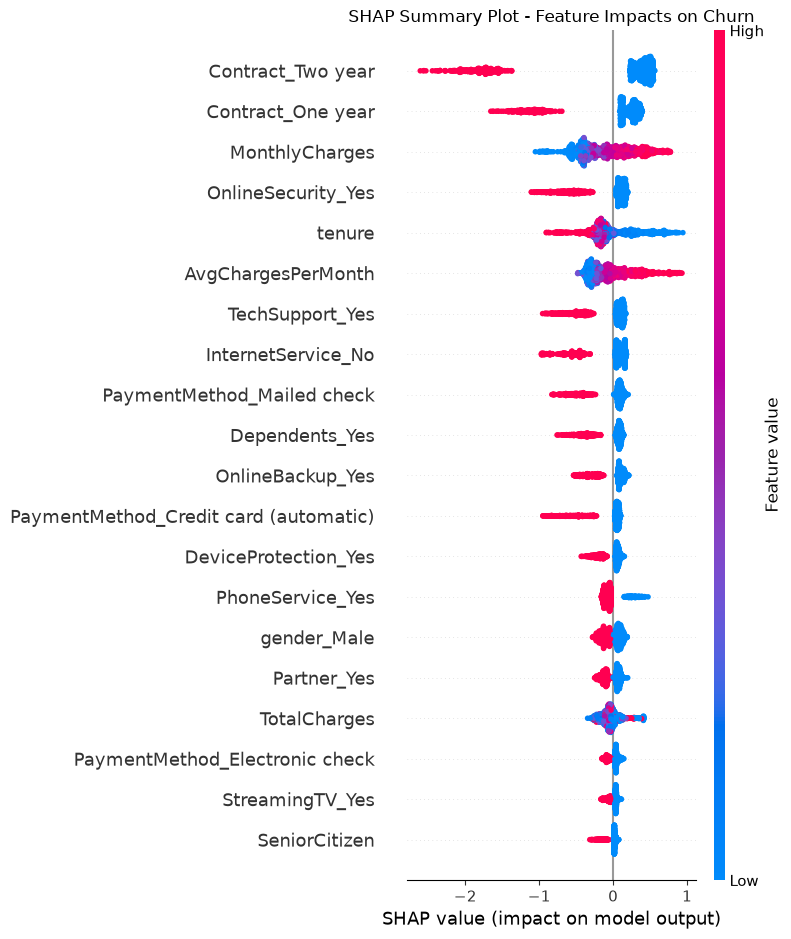

In [2]:
# Initialize JS visualization code
shap.initjs()

# Create explainer and compute SHAP values
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Plot summary
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Summary Plot - Feature Impacts on Churn")
plt.tight_layout()
plt.show()


## SHAP Dependence Plots
Dependence plots show the relationship between a single feature and its impact on the prediction, including interactions with other features.

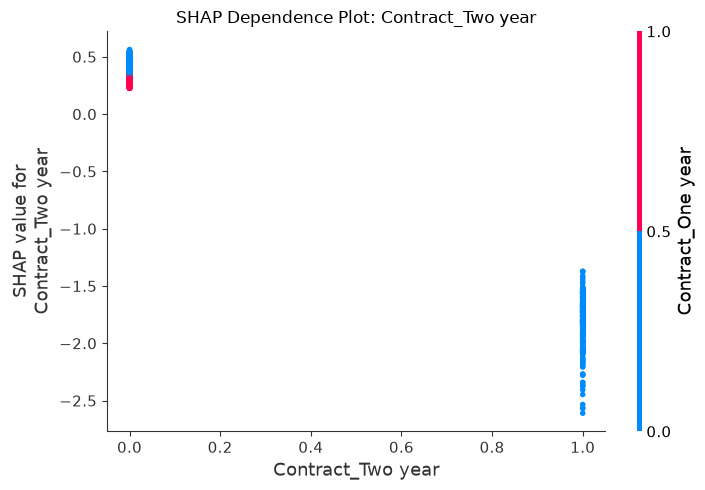

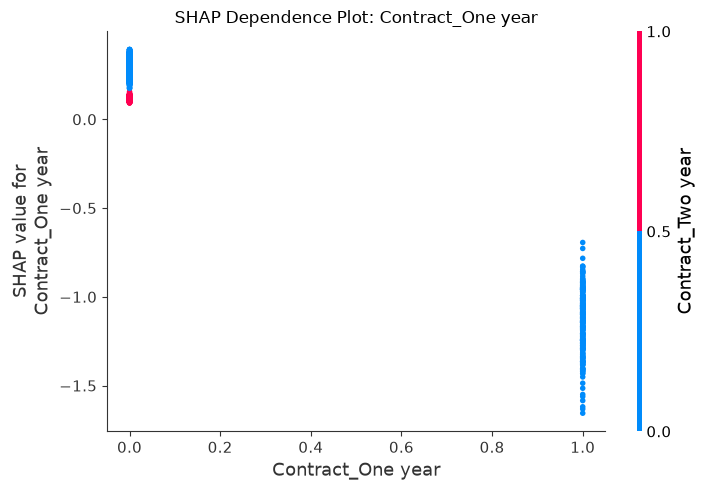

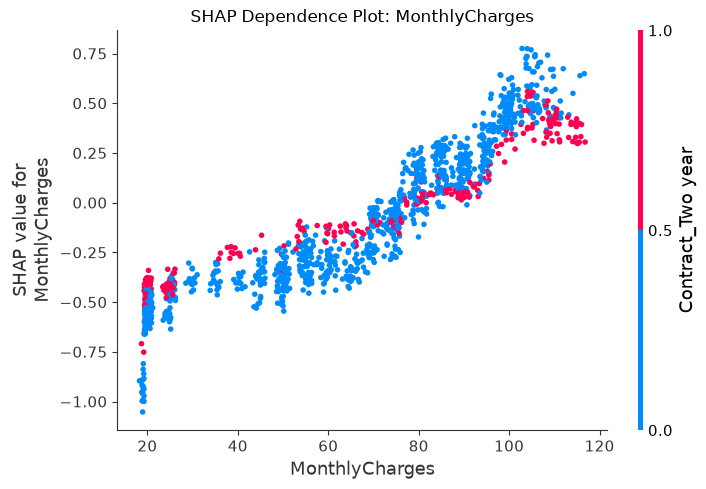

In [3]:
# Top 3 features by mean absolute SHAP value
mean_shap = np.abs(shap_values).mean(axis=0)
top_features = X_test.columns[np.argsort(mean_shap)[::-1][:3]]

for feature in top_features:
    shap.dependence_plot(feature, shap_values, X_test, show=False)
    plt.title(f"SHAP Dependence Plot: {feature}")
    plt.tight_layout()
    plt.show()


## Key Takeaways
From the SHAP plots, we can see exactly which customer profiles are most likely to churn. For example, customers with short tenure, high monthly charges, and month-to-month contracts typically have strong positive SHAP values (pushing prediction towards Churn). We will compile these into concrete business recommendations in M16.